# Drift Monitoring on Real Case-Study Artifacts

**Chapter 26: MLOps and Governance**
**Docker image**: `ml4t`
**Book Reference**: Chapter 26, Sections 26.2-26.3
**Prerequisites**: Chapter 25 deployment verification and basic performance metrics.

**Learning Objectives**:
- Compute PSI, K-S, and rolling diagnostics on the real `us_equities_panel` holdout window.
- Separate data-quality failures from genuine distribution change.
- Build a compact monitoring dashboard from stored feature and prediction artifacts.

In [1]:
"""Drift Monitoring on Real Case-Study Artifacts — compute PSI, K-S, and rolling diagnostics on the real holdout window."""

'Drift Monitoring on Real Case-Study Artifacts — compute PSI, K-S, and rolling diagnostics on the real holdout window.'

In [2]:
CASE_STUDY_ID = "us_equities_panel"
# Monitor the one model with a sealed-holdout prediction set in this case
# study's registry: the GBM fwd_ret_5d run. The linear models produced only
# cross-validation / validation predictions, never a holdout set, so monitoring
# them would mean labelling a validation window as "holdout".
PRIMARY_LABEL = "fwd_ret_5d"
REFERENCE_START = "2015-01-01"
LOOKBACK_DAYS = 63
KS_WATCH_PVALUE = 0.05  # §26.3 K-S trigger
SEED = 42

In [3]:
import json
import sqlite3
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Literal

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import yaml
from ml4t.diagnostic.validation import DataFrameValidator
from scipy import stats

from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, format_pct_axis

warnings.filterwarnings("ignore")

set_global_seeds(SEED)

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP_PATH = CASE_DIR / "config" / "setup.yaml"
REGISTRY_PATH = CASE_DIR / "run_log" / "registry.db"

FEATURE_COLUMNS = [
    "past_ret_21d",
    "vol_21d",
    "rsi_14",
    "volume_ratio",
    "garch_cond_vol",
]

print("Drift Monitoring on Real Holdout Data")
print("=" * 60)

Drift Monitoring on Real Holdout Data


## 1. Load the real monitoring boundary

The notebook uses the actual sealed holdout window from `setup.yaml`.
Features before the holdout act as the reference distribution; the latest
holdout window acts as the live production slice.

In [4]:
def load_holdout_window(setup_path: Path) -> tuple[pd.Timestamp, pd.Timestamp]:
    setup = yaml.safe_load(setup_path.read_text())
    evaluation = setup["evaluation"]
    return pd.Timestamp(evaluation["holdout_start"]), pd.Timestamp(evaluation["holdout_end"])

### Load the holdout prediction artifact
Find the content-addressed prediction hash for the sealed-holdout model run.

In [5]:
def load_holdout_prediction_hash(registry_path: Path) -> tuple[str, str]:
    """Locate the sealed-holdout prediction artifact for ``PRIMARY_LABEL``.

    Selects a materialized ``split='holdout'`` prediction set. Validation
    predictions are never relabeled as holdout data.
    """
    query = """
        SELECT ps.prediction_hash, tr.family
        FROM training_runs tr
        JOIN prediction_sets ps ON tr.training_hash = ps.training_hash
        WHERE tr.label = ? {split_filter}
        ORDER BY tr.created_at DESC
    """
    pred_dir = registry_path.parent / "predictions"
    with sqlite3.connect(registry_path) as conn:
        rows = conn.execute(
            query.format(split_filter="AND ps.split = 'holdout'"), (PRIMARY_LABEL,)
        ).fetchall()
    for pred_hash, family in rows:
        if (pred_dir / str(pred_hash) / "predictions.parquet").exists():
            return str(pred_hash), str(family)
    raise RuntimeError("No materialized sealed-holdout prediction artifact is available.")

In [6]:
holdout_start, holdout_end = load_holdout_window(SETUP_PATH)
holdout_run_hash, holdout_model_family = load_holdout_prediction_hash(REGISTRY_PATH)

_pred_check_path = CASE_DIR / "run_log" / "predictions" / holdout_run_hash / "predictions.parquet"
_pred_bounds = (
    pl.scan_parquet(_pred_check_path)
    .select(pl.min("timestamp").alias("start"), pl.max("timestamp").alias("end"))
    .collect()
    .row(0)
)
_pred_start, _pred_end = (pd.Timestamp(value) for value in _pred_bounds)
_label_bounds = (
    pl.scan_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
    .filter(pl.col("timestamp").is_between(holdout_start.date(), holdout_end.date()))
    .select(pl.min("timestamp").alias("start"), pl.max("timestamp").alias("end"))
    .collect()
    .row(0)
)
_label_start, _label_end = (pd.Timestamp(value) for value in _label_bounds)
assert (_pred_start, _pred_end) == (_label_start, _label_end), (
    f"Holdout predictions cover {_pred_start.date()} to {_pred_end.date()}, "
    f"not all label-eligible sessions {_label_start.date()} to {_label_end.date()}"
)

print(f"Holdout window: {holdout_start.date()} to {holdout_end.date()}")
print(f"Holdout prediction run: {holdout_run_hash} ({holdout_model_family}, {PRIMARY_LABEL})")

Holdout window: 2016-01-01 to 2018-03-31
Holdout prediction run: e17247d66c6c (gbm, fwd_ret_5d)


## 2. Validate incoming features before measuring drift

A broken join or null-filled feature column can look like drift. Validation
happens first so monitoring is not diagnosing a pipeline failure as a market
change.

In [7]:
def validate_feature_data(features_df: pl.DataFrame, required_columns: list[str]) -> None:
    validator = DataFrameValidator(features_df)
    validator.check_empty().check_min_rows(min_rows=100).require_columns(required_columns)
    validator.check_nulls(columns=required_columns, allow_nulls=False)
    print(f"Validated {len(features_df):,} rows across {len(required_columns)} monitored features.")

### Resolve fitted feature state by walk-forward fold

`model_based.parquet` stores one fitted feature vintage per fold. Each date
must use its validation fold, while the sealed holdout uses the dedicated
final fold fitted only on pre-holdout observations.

In [8]:
def load_temporal_panel(start_date: object, end_date: object, columns: list[str]) -> pl.DataFrame:
    timeline = (
        pl.scan_parquet(CASE_DIR / "features" / "financial.parquet")
        .select("timestamp")
        .unique()
        .collect()
    )
    splits = generate_cv_splits(timeline, case_study_id=CASE_STUDY_ID, label_buffer="1D")
    temporal = pl.scan_parquet(CASE_DIR / "features" / "model_based.parquet")
    holdout_fold = temporal.select(pl.max("fold")).collect().item()
    windows = [
        (
            split["fold"],
            pd.Timestamp(split["val_start"]).date(),
            pd.Timestamp(split["val_end"]).date(),
        )
        for split in splits
    ]
    windows.append((holdout_fold, holdout_start.date(), holdout_end.date()))

    frames = [
        temporal.filter(
            (pl.col("fold") == fold)
            & pl.col("timestamp").is_between(
                max(start_date, window_start), min(end_date, window_end)
            )
        ).select(["symbol", "timestamp", *columns])
        for fold, window_start, window_end in windows
        if window_start <= end_date and window_end >= start_date
    ]
    result = pl.concat(frames).collect().sort(["timestamp", "symbol"])
    duplicate_keys = result.select(pl.struct("symbol", "timestamp").is_duplicated().any()).item()
    assert duplicate_keys is False
    return result

### Load feature panel
Join financial and model-based feature parquets over the requested date range.

In [9]:
def load_feature_panel(start: str, end: str, feature_columns: list[str]) -> pl.DataFrame:
    start_date = pd.Timestamp(start).date()
    end_date = pd.Timestamp(end).date()
    financial_cols = [c for c in feature_columns if c != "garch_cond_vol"]
    model_cols = [c for c in feature_columns if c == "garch_cond_vol"]

    financial = (
        pl.scan_parquet(CASE_DIR / "features" / "financial.parquet")
        .filter(
            (pl.col("timestamp") >= pl.lit(start_date)) & (pl.col("timestamp") <= pl.lit(end_date))
        )
        .select(["symbol", "timestamp", *financial_cols])
    )
    model_based = load_temporal_panel(start_date, end_date, model_cols).lazy()

    return (
        financial.join(model_based, on=["symbol", "timestamp"], how="inner")
        .drop_nulls(feature_columns)
        .collect()
    )

### Load holdout predictions
Read the content-addressed prediction parquet for the sealed-holdout run.

In [10]:
def load_holdout_predictions(run_hash: str) -> pl.DataFrame:
    pred_path = CASE_DIR / "run_log" / "predictions" / run_hash / "predictions.parquet"
    lf = pl.scan_parquet(pred_path)
    # Normalize legacy column names
    cols = lf.collect_schema().names()
    renames = {}
    if "actual" in cols and "y_true" not in cols:
        renames["actual"] = "y_true"
    if "prediction" in cols and "y_score" not in cols:
        renames["prediction"] = "y_score"
    if renames:
        lf = lf.rename(renames)
    return (
        lf.select(
            pl.col("timestamp").cast(pl.Date).alias("timestamp"),
            pl.col("symbol"),
            pl.col("y_score").alias("score"),
            pl.col("y_true").alias("actual_return"),
        )
        .collect()
        .sort(["timestamp", "symbol"])
    )

In [11]:
reference_features = load_feature_panel(
    REFERENCE_START, str(holdout_start.date() - pd.Timedelta(days=1)), FEATURE_COLUMNS
)
# Restrict the artifact to the configured sealed holdout window.
holdout_predictions = load_holdout_predictions(holdout_run_hash).filter(
    (pl.col("timestamp") >= holdout_start.date()) & (pl.col("timestamp") <= holdout_end.date())
)
holdout_dates = holdout_predictions.get_column("timestamp").unique().sort().to_list()
assert len(holdout_dates) >= 2 * LOOKBACK_DAYS, (
    "Holdout is too short for distinct monitoring windows"
)
launch_dates = holdout_dates[:LOOKBACK_DAYS]
current_window_dates = holdout_dates[-LOOKBACK_DAYS:]
current_window_start = pd.Timestamp(current_window_dates[0])
current_window_end = pd.Timestamp(current_window_dates[-1])
current_features = load_feature_panel(
    str(current_window_start.date()), str(current_window_end.date()), FEATURE_COLUMNS
)

validate_feature_data(current_features, FEATURE_COLUMNS)
validate_feature_data(reference_features, FEATURE_COLUMNS)

print(f"Reference feature rows: {reference_features.height:,}")
print(f"Current feature rows:   {current_features.height:,}")

Validated 129,145 rows across 5 monitored features.
Validated 612,503 rows across 5 monitored features.
Reference feature rows: 612,503
Current feature rows:   129,145


## 3. Feature and prediction drift diagnostics

The reference set is the last pre-holdout year. The current slice is the most
recent 63 trading days inside the holdout. PSI flags material shifts, while
the K-S test checks whether the two samples plausibly come from the same
distribution.

In [12]:
def compute_psi(
    reference: np.ndarray,
    current: np.ndarray,
    n_bins: int = 10,
    epsilon: float = 1e-6,
) -> tuple[float, np.ndarray]:
    # Explicit bin edges avoid numpy 2.2.x histogram regression.
    # Standard PSI defines bins from the reference distribution only — letting
    # the current set stretch the range concentrates reference mass into fewer
    # bins under genuine drift and reduces sensitivity. Outer ±inf edges
    # capture current values that fall outside the reference range so
    # regime shifts to new extremes amplify PSI rather than drop silently.
    inner = np.linspace(reference.min(), reference.max(), n_bins + 1)[1:-1]
    bin_edges = np.concatenate([[-np.inf], inner, [np.inf]])
    ref_counts, _ = np.histogram(reference, bins=bin_edges)
    cur_counts, _ = np.histogram(current, bins=bin_edges)
    ref_pct = ref_counts / len(reference) + epsilon
    cur_pct = cur_counts / len(current) + epsilon
    bin_psi = (cur_pct - ref_pct) * np.log(cur_pct / ref_pct)
    return float(np.sum(bin_psi)), bin_psi

### Drift metric container
A typed container for per-feature drift statistics and alert status.

In [13]:
@dataclass
class DriftMetric:
    name: str
    psi: float
    ks_stat: float
    ks_pvalue: float
    reference_mean: float
    current_mean: float
    status: Literal["OK", "WATCH", "ALERT"]

### Polars-to-numpy helper
Extract a single column as a float numpy array, dropping nulls.

In [14]:
def to_numpy(frame: pl.DataFrame, column: str) -> np.ndarray:
    values = frame.get_column(column).drop_nulls().to_numpy()
    return np.asarray(values, dtype=float)

### Summarize feature drift
Compute PSI and K-S for each monitored feature and assign alert levels.

In [15]:
def summarize_feature_drift(
    reference_frame: pl.DataFrame,
    current_frame: pl.DataFrame,
    feature_columns: list[str],
) -> list[DriftMetric]:
    metrics: list[DriftMetric] = []
    for feature in feature_columns:
        reference = to_numpy(reference_frame, feature)
        current = to_numpy(current_frame, feature)
        psi, _ = compute_psi(reference, current)
        ks_stat, ks_pvalue = stats.ks_2samp(reference, current)
        if psi >= 0.25:
            status = "ALERT"
        elif psi >= 0.10 or (psi >= 0.02 and ks_pvalue < KS_WATCH_PVALUE):
            status = "WATCH"
        else:
            status = "OK"
        metrics.append(
            DriftMetric(
                name=feature,
                psi=psi,
                ks_stat=float(ks_stat),
                ks_pvalue=float(ks_pvalue),
                reference_mean=float(reference.mean()),
                current_mean=float(current.mean()),
                status=status,
            )
        )
    return metrics

In [16]:
feature_drift = summarize_feature_drift(reference_features, current_features, FEATURE_COLUMNS)
feature_drift_df = pd.DataFrame([metric.__dict__ for metric in feature_drift]).sort_values(
    "psi", ascending=False
)
feature_drift_df

,name,psi,ks_stat,ks_pvalue,reference_mean,current_mean,status
2,rsi_14,0.017079,0.043018,6.044090e-172,50.174849,51.338291,OK
1,vol_21d,0.016964,0.041010,2.648221e-156,0.327967,0.308591,OK
0,past_ret_21d,0.012861,0.035736,8.868094e-119,0.000649,0.007667,OK
3,volume_ratio,0.002732,0.020589,1.043431e-39,0.998293,1.008263,OK
4,garch_cond_vol,0.000736,0.396115,0.000000e+00,0.160160,0.150914,OK


In [17]:
baseline_predictions = (
    holdout_predictions.filter(pl.col("timestamp").is_in(launch_dates))
    .select("score")
    .to_series()
    .to_numpy()
)
recent_predictions = (
    holdout_predictions.filter(pl.col("timestamp").is_in(current_window_dates))
    .select("score")
    .to_series()
    .to_numpy()
)

prediction_psi, _ = compute_psi(baseline_predictions, recent_predictions)
prediction_ks = stats.ks_2samp(baseline_predictions, recent_predictions)

print(f"Prediction PSI: {prediction_psi:.4f}")
print(f"Prediction K-S p-value: {prediction_ks.pvalue:.4f}")

Prediction PSI: 0.1900
Prediction K-S p-value: 0.0000


**Finding**: The feature with the largest PSI sets the headline distribution
move; the prediction-side PSI then confirms whether that input shift is
propagating into model output. Read the numbers directly from
`feature_drift_df` and the printed prediction PSI above — when the top feature
crosses the `0.10` WATCH bar (or `0.25` ALERT), the prediction PSI should
move in sympathy or the desk should look for an upstream pipeline cause.

## 4. Rolling performance diagnostics on the holdout stream

The first 63 holdout sessions act as the launch baseline. Monitoring then
tracks whether later 63-day windows retain similar IC and hit-rate behavior.

In [18]:
daily_metrics = (
    holdout_predictions.group_by("timestamp")
    .agg(
        pl.corr("score", "actual_return").alias("ic"),
        ((pl.col("score") * pl.col("actual_return")) > 0).mean().alias("hit_rate"),
        ((pl.col("actual_return") - pl.col("score")) ** 2).mean().alias("mse"),
        pl.col("score").mean().alias("score_mean"),
        pl.col("score").std().alias("score_std"),
        pl.len().alias("n_assets"),
    )
    .sort("timestamp")
    .to_pandas()
)

daily_metrics["timestamp"] = pd.to_datetime(daily_metrics["timestamp"])
daily_metrics["rolling_ic_63"] = daily_metrics["ic"].rolling(LOOKBACK_DAYS, min_periods=21).mean()
daily_metrics["rolling_hit_rate_63"] = (
    daily_metrics["hit_rate"].rolling(LOOKBACK_DAYS, min_periods=21).mean()
)
daily_metrics["rolling_mse_63"] = daily_metrics["mse"].rolling(LOOKBACK_DAYS, min_periods=21).mean()

baseline_slice = daily_metrics.iloc[:LOOKBACK_DAYS]
current_slice = daily_metrics.iloc[-LOOKBACK_DAYS:]

baseline_ic = baseline_slice["ic"].mean()
baseline_hit_rate = baseline_slice["hit_rate"].mean()
baseline_mse = baseline_slice["mse"].mean()
current_ic = current_slice["ic"].mean()
current_hit_rate = current_slice["hit_rate"].mean()
current_mse = current_slice["mse"].mean()

In [19]:
alert_rows = [
    {
        "metric": "prediction_distribution",
        "baseline": 0.0,
        "current": prediction_psi,
        "threshold": 0.10,
        "status": "ALERT"
        if prediction_psi >= 0.25
        else ("WATCH" if prediction_psi >= 0.10 else "OK"),
    },
    {
        "metric": "rolling_ic_63",
        "baseline": baseline_ic,
        "current": current_ic,
        "threshold": baseline_ic - 0.01,
        "status": "ALERT"
        if current_ic < baseline_ic - 0.01
        else ("WATCH" if current_ic < baseline_ic - 0.005 else "OK"),
    },
    {
        "metric": "rolling_hit_rate_63",
        "baseline": baseline_hit_rate,
        "current": current_hit_rate,
        "threshold": baseline_hit_rate - 0.01,
        "status": "ALERT"
        if current_hit_rate < baseline_hit_rate - 0.01
        else ("WATCH" if current_hit_rate < baseline_hit_rate - 0.005 else "OK"),
    },
    {
        "metric": "rolling_mse_63",
        "baseline": baseline_mse,
        "current": current_mse,
        "threshold": baseline_mse * 1.10,
        "status": "ALERT"
        if current_mse > baseline_mse * 1.10
        else ("WATCH" if current_mse > baseline_mse * 1.05 else "OK"),
    },
]

alert_table = pd.DataFrame(alert_rows)
alert_table

,metric,baseline,current,threshold,status
0,prediction_distribution,0.000000,0.190036,0.100000,WATCH
1,rolling_ic_63,-0.003490,-0.016674,-0.013490,ALERT
2,rolling_hit_rate_63,0.451128,0.499266,0.441128,OK
3,rolling_mse_63,0.014838,0.007519,0.016321,OK


## 5. Monitoring dashboard

The dashboard combines feature drift, output drift, and rolling signal quality
into one review surface. A desk can inspect this view before deciding whether
to investigate data quality, reduce exposure, or start a model update.

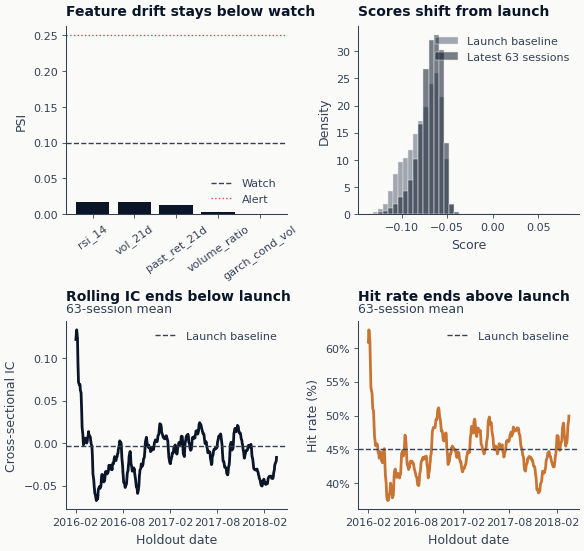

In [20]:
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE["dashboard_2x2"], constrained_layout=True)
max_psi = float(feature_drift_df["psi"].max())
psi_title = "Feature drift stays below watch" if max_psi < 0.10 else "Feature drift crosses watch"

ax1 = axes[0, 0]
colors = feature_drift_df["status"].map(
    {"OK": COLORS["blue"], "WATCH": COLORS["amber"], "ALERT": COLORS["negative"]}
)
ax1.bar(feature_drift_df["name"], feature_drift_df["psi"], color=colors)
ax1.axhline(0.10, color=COLORS["neutral"], linestyle="--", linewidth=1, label="Watch")
ax1.axhline(0.25, color=COLORS["negative"], linestyle=":", linewidth=1, label="Alert")
add_message_title(ax1, psi_title)
ax1.set_ylabel("PSI")
ax1.tick_params(axis="x", rotation=35)
ax1.legend()

ax2 = axes[0, 1]
# Explicit edges avoid numpy 2.2.x histogram regression with integer bins
_lo = min(baseline_predictions.min(), recent_predictions.min())
_hi = max(baseline_predictions.max(), recent_predictions.max())
_edges = np.linspace(_lo, _hi, 41)
sns.histplot(
    baseline_predictions,
    bins=_edges,
    stat="density",
    color=COLORS["neutral"],
    alpha=0.45,
    ax=ax2,
)
sns.histplot(
    recent_predictions,
    bins=_edges,
    stat="density",
    color=COLORS["blue"],
    alpha=0.55,
    ax=ax2,
)
add_message_title(ax2, "Scores shift from launch")
ax2.set_xlabel("Score")
ax2.legend(["Launch baseline", "Latest 63 sessions"])

ax3 = axes[1, 0]
ax3.plot(
    daily_metrics["timestamp"], daily_metrics["rolling_ic_63"], color=COLORS["blue"], linewidth=2
)
ax3.axhline(
    baseline_ic, color=COLORS["neutral"], linestyle="--", linewidth=1, label="Launch baseline"
)
ic_direction = "above" if daily_metrics["rolling_ic_63"].iloc[-1] >= baseline_ic else "below"
add_message_title(ax3, f"Rolling IC ends {ic_direction} launch", subtitle="63-session mean")
ax3.set_ylabel("Cross-sectional IC")
ax3.set_xlabel("Holdout date")
ax3.legend()

ax4 = axes[1, 1]
ax4.plot(
    daily_metrics["timestamp"],
    daily_metrics["rolling_hit_rate_63"],
    color=COLORS["copper"],
    linewidth=2,
)
ax4.axhline(
    baseline_hit_rate,
    color=COLORS["neutral"],
    linestyle="--",
    linewidth=1,
    label="Launch baseline",
)
hit_direction = (
    "above" if daily_metrics["rolling_hit_rate_63"].iloc[-1] >= baseline_hit_rate else "below"
)
add_message_title(
    ax4,
    f"Hit rate ends {hit_direction} launch",
    subtitle="63-session mean",
)
ax4.set_ylabel("Hit rate (%)")
ax4.set_xlabel("Holdout date")
format_pct_axis(ax4)
ax4.legend()

for axis in (ax3, ax4):
    axis.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.show()

### Persist artifacts for the publication figure

The book-side script renders Figure 26.2 from these arrays so the publication
build does not re-execute the notebook.

In [21]:
ARTIFACT_DIR = get_output_dir(26, "figure_26_2")

feature_drift_df[["name", "psi", "status"]].to_parquet(
    ARTIFACT_DIR / "feature_drift.parquet", index=False
)
np.save(ARTIFACT_DIR / "baseline_predictions.npy", baseline_predictions)
np.save(ARTIFACT_DIR / "recent_predictions.npy", recent_predictions)
daily_metrics[["timestamp", "rolling_ic_63", "rolling_hit_rate_63"]].to_parquet(
    ARTIFACT_DIR / "daily_metrics.parquet", index=False
)
_ = (ARTIFACT_DIR / "scalars.json").write_text(
    json.dumps(
        {"baseline_ic": float(baseline_ic), "baseline_hit_rate": float(baseline_hit_rate)}, indent=2
    )
)

### Feature drift summary

In [22]:
feature_drift_df[["name", "psi", "ks_pvalue", "status", "reference_mean", "current_mean"]]

,name,psi,ks_pvalue,status,reference_mean,current_mean
2,rsi_14,0.017079,6.044090e-172,OK,50.174849,51.338291
1,vol_21d,0.016964,2.648221e-156,OK,0.327967,0.308591
0,past_ret_21d,0.012861,8.868094e-119,OK,0.000649,0.007667
3,volume_ratio,0.002732,1.043431e-39,OK,0.998293,1.008263
4,garch_cond_vol,0.000736,0.000000e+00,OK,0.160160,0.150914


### Alert table

In [23]:
alert_table

,metric,baseline,current,threshold,status
0,prediction_distribution,0.000000,0.190036,0.100000,WATCH
1,rolling_ic_63,-0.003490,-0.016674,-0.013490,ALERT
2,rolling_hit_rate_63,0.451128,0.499266,0.441128,OK
3,rolling_mse_63,0.014838,0.007519,0.016321,OK


**Finding**: The alert table converts the diagnostics above into operating
state. Each row reports the launch baseline (first 63 holdout sessions), the
current 63-day window, and the threshold that separates OK / WATCH / ALERT.
IC and hit-rate use a 0.005 watch / 0.01 alert buffer relative to baseline;
MSE uses a 5% / 10% relative increase. The status column is the actionable
read — investigate any non-OK row before the next monitoring cycle.

**Trading implication**: This monitoring view is not a retraining trigger by
itself. It is the evidence package for the next decision: confirm data
integrity, isolate which distributions moved, and only then decide whether a
workflow like shadow testing or staged rollout is warranted.

## Key Takeaways

1. PSI and K-S tests on the real holdout window separate genuine distribution change from data-quality issues when validation precedes drift measurement.
2. Rolling IC and hit-rate diagnostics track whether model signal quality is degrading over time.
3. The monitoring dashboard combines feature drift, output drift, and rolling performance into one review surface for operational decision-making.

**Next**: See `02_online_drift_detection` for sequential drift detectors on the same validation streams.